Практична робота #2. Завдання 2.3–2.6

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

%matplotlib inline

2.3. Класифікація логістичною регресією

In [8]:

def visualize_classifier(classifier, X, y):
    import numpy as np
    import matplotlib.pyplot as plt

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="black", cmap="viridis")
    plt.xlabel("Ознака 1")
    plt.ylabel("Ознака 2")
    plt.title("Класифікація логістичною регресією")
    plt.show()

Точність моделі: 100.0 %


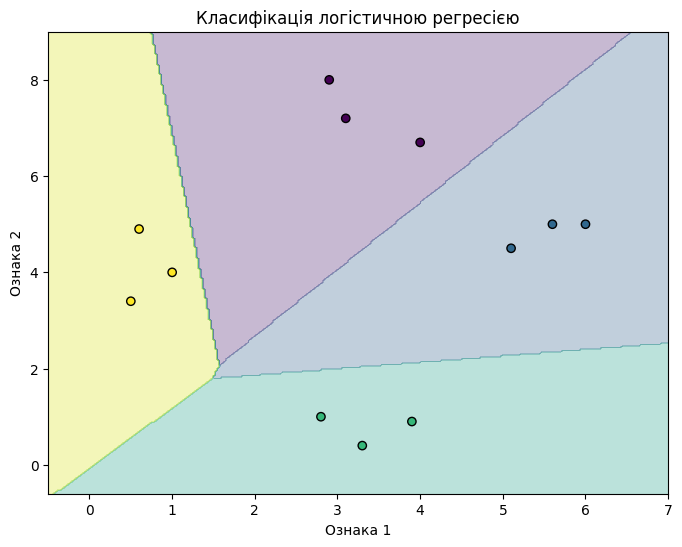

In [9]:
X = np.array([
    [3.1, 7.2], [4, 6.7], [2.9, 8],
    [5.1, 4.5], [6, 5], [5.6, 5],
    [3.3, 0.4], [3.9, 0.9], [2.8, 1],
    [0.5, 3.4], [1, 4], [0.6, 4.9]
])

y = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3])

classifier = LogisticRegression(
    solver="liblinear",
    C=1
)

classifier.fit(X, y)

print("Точність моделі:",
      round(classifier.score(X, y) * 100, 2), "%")

visualize_classifier(classifier, X, y)

2.4. Наївний байєсівський класифікатор

Accuracy: 100.0 %
Precision: 100.0 %
Recall: 100.0 %
F1: 100.0 %

Матриця помилок:
[[20  0  0  0]
 [ 0 17  0  0]
 [ 0  0 24  0]
 [ 0  0  0 19]]

Звіт класифікації:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        20
         1.0       1.00      1.00      1.00        17
         2.0       1.00      1.00      1.00        24
         3.0       1.00      1.00      1.00        19

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



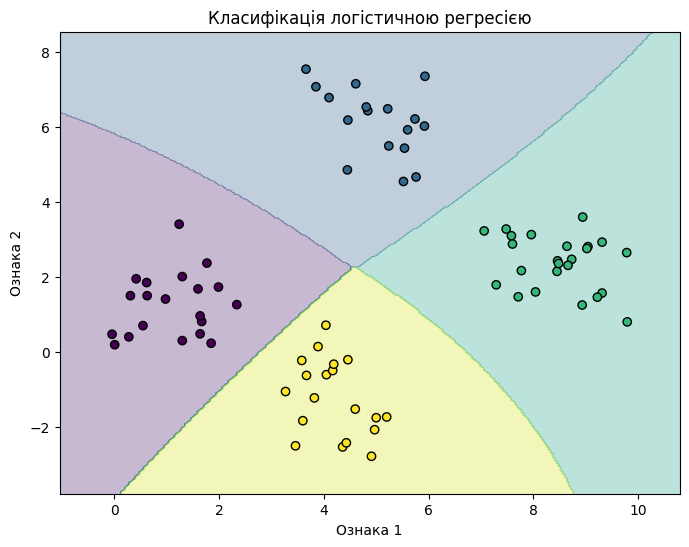

In [11]:
data = np.loadtxt("data_multivar_nb.txt", delimiter=",")

X = data[:, :-1]
y = data[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=3
)

classifier = GaussianNB()
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Precision:", round(precision_score(
    y_test, y_pred, average="weighted", zero_division=0
) * 100, 2), "%")
print("Recall:", round(recall_score(
    y_test, y_pred, average="weighted", zero_division=0
) * 100, 2), "%")
print("F1:", round(f1_score(
    y_test, y_pred, average="weighted", zero_division=0
) * 100, 2), "%")

print("\nМатриця помилок:")
print(confusion_matrix(y_test, y_pred))

print("\nЗвіт класифікації:")
print(__import__('sklearn.metrics', fromlist=['classification_report']).classification_report(y_test, y_pred, zero_division=0))

visualize_classifier(classifier, X_test, y_test)

2.5. Метрики якості класифікації

In [12]:
df = pd.read_csv("data_metrics.csv")

df["predicted_RF"] = (df["model_RF"] >= 0.5).astype(int)
df["predicted_LR"] = (df["model_LR"] >= 0.5).astype(int)

def find_TP(y_true, y_pred):
    return int(np.sum((y_true == 1) & (y_pred == 1)))

def find_FN(y_true, y_pred):
    return int(np.sum((y_true == 1) & (y_pred == 0)))

def find_FP(y_true, y_pred):
    return int(np.sum((y_true == 0) & (y_pred == 1)))

def find_TN(y_true, y_pred):
    return int(np.sum((y_true == 0) & (y_pred == 0)))

def find_conf_matrix_values(y_true, y_pred):
    return (
        find_TP(y_true, y_pred),
        find_FN(y_true, y_pred),
        find_FP(y_true, y_pred),
        find_TN(y_true, y_pred)
    )

def my_confusion_matrix(y_true, y_pred):
    TP, FN, FP, TN = find_conf_matrix_values(y_true, y_pred)
    return np.array([[TN, FP], [FN, TP]])

def my_accuracy_score(y_true, y_pred):
    TP, FN, FP, TN = find_conf_matrix_values(y_true, y_pred)
    return (TP + TN) / (TP + FN + FP + TN)

def my_recall_score(y_true, y_pred):
    TP, FN, FP, TN = find_conf_matrix_values(y_true, y_pred)
    return TP / (TP + FN) if TP + FN else 0

def my_precision_score(y_true, y_pred):
    TP, FN, FP, TN = find_conf_matrix_values(y_true, y_pred)
    return TP / (TP + FP) if TP + FP else 0

def my_f1_score(y_true, y_pred):
    precision = my_precision_score(y_true, y_pred)
    recall = my_recall_score(y_true, y_pred)
    return (
        2 * precision * recall / (precision + recall)
        if precision + recall else 0
    )

y_true = df["actual_label"].values
y_rf = df["predicted_RF"].values
y_lr = df["predicted_LR"].values

for name, predictions in [("RF", y_rf), ("LR", y_lr)]:
    print(f"\nМодель {name}")
    print("Матриця помилок:")
    print(my_confusion_matrix(y_true, predictions))
    print("Accuracy:", round(my_accuracy_score(y_true, predictions), 3))
    print("Recall:", round(my_recall_score(y_true, predictions), 3))
    print("Precision:", round(my_precision_score(y_true, predictions), 3))
    print("F1:", round(my_f1_score(y_true, predictions), 3))

    assert np.array_equal(
        my_confusion_matrix(y_true, predictions),
        confusion_matrix(y_true, predictions)
    )

    assert np.isclose(
        my_accuracy_score(y_true, predictions),
        accuracy_score(y_true, predictions)
    )

    assert np.isclose(
        my_recall_score(y_true, predictions),
        recall_score(y_true, predictions)
    )

    assert np.isclose(
        my_precision_score(y_true, predictions),
        precision_score(y_true, predictions)
    )

    assert np.isclose(
        my_f1_score(y_true, predictions),
        f1_score(y_true, predictions)
    )

print("\nПеревірка власних функцій пройдена.")


Модель RF
Матриця помилок:
[[5519 2360]
 [2832 5047]]
Accuracy: 0.671
Recall: 0.641
Precision: 0.681
F1: 0.66

Модель LR
Матриця помилок:
[[5425 2454]
 [3600 4279]]
Accuracy: 0.616
Recall: 0.543
Precision: 0.636
F1: 0.586

Перевірка власних функцій пройдена.



Модель RF, поріг 0.5
Accuracy: 0.671
Recall: 0.641
Precision: 0.681
F1: 0.66

Модель RF, поріг 0.25
Accuracy: 0.502
Recall: 1.0
Precision: 0.501
F1: 0.668

AUC RF: 0.738
AUC LR: 0.666


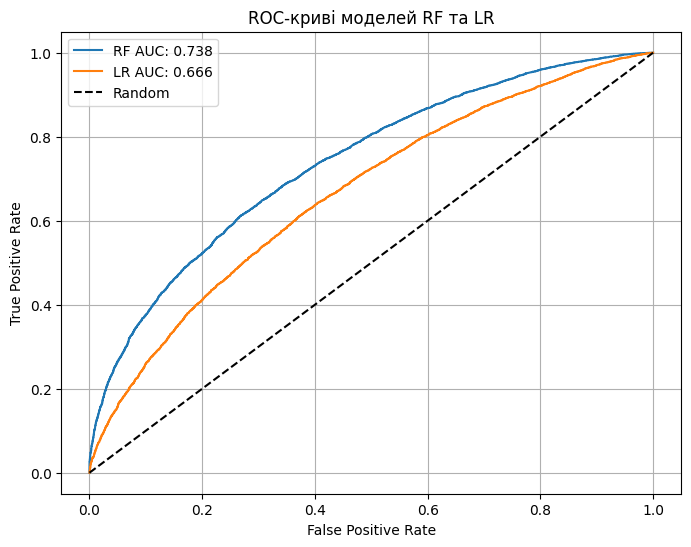

In [13]:
for threshold in [0.5, 0.25]:
    predictions = (df["model_RF"].values >= threshold).astype(int)

    print(f"\nМодель RF, поріг {threshold}")
    print("Accuracy:", round(accuracy_score(y_true, predictions), 3))
    print("Recall:", round(recall_score(y_true, predictions), 3))
    print("Precision:", round(precision_score(y_true, predictions), 3))
    print("F1:", round(f1_score(y_true, predictions), 3))

fpr_rf, tpr_rf, _ = roc_curve(y_true, df["model_RF"].values)
fpr_lr, tpr_lr, _ = roc_curve(y_true, df["model_LR"].values)

auc_rf = roc_auc_score(y_true, df["model_RF"].values)
auc_lr = roc_auc_score(y_true, df["model_LR"].values)

print("\nAUC RF:", round(auc_rf, 3))
print("AUC LR:", round(auc_lr, 3))

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"RF AUC: {auc_rf:.3f}")
plt.plot(fpr_lr, tpr_lr, label=f"LR AUC: {auc_lr:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-криві моделей RF та LR")
plt.legend()
plt.grid(True)
plt.show()

2.6. Класифікація методом опорних векторів


Support Vector Machine
Accuracy: 100.0 %
Precision: 100.0 %
Recall: 100.0 %
F1: 100.0 %
Матриця помилок:
[[20  0  0  0]
 [ 0 17  0  0]
 [ 0  0 24  0]
 [ 0  0  0 19]]

Gaussian Naive Bayes
Accuracy: 100.0 %
Precision: 100.0 %
Recall: 100.0 %
F1: 100.0 %
Матриця помилок:
[[20  0  0  0]
 [ 0 17  0  0]
 [ 0  0 24  0]
 [ 0  0  0 19]]


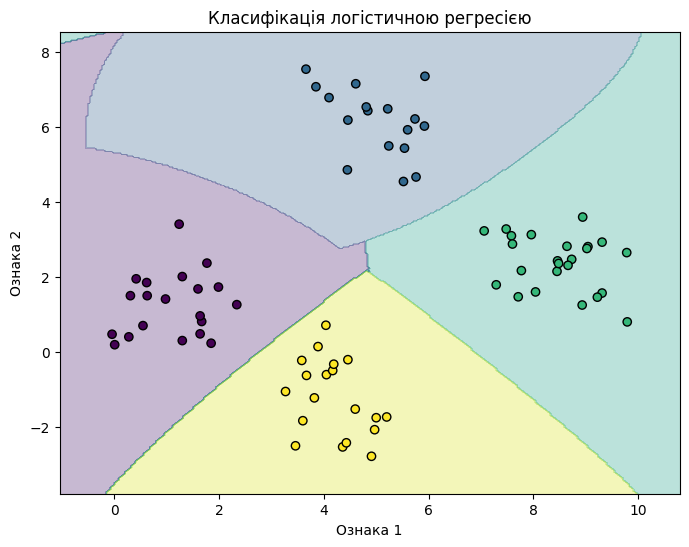

In [14]:
data = np.loadtxt("data_multivar_nb.txt", delimiter=",")

X = data[:, :-1]
y = data[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=3
)

svm_classifier = SVC(kernel="rbf")
svm_classifier.fit(X_train, y_train)

svm_pred = svm_classifier.predict(X_test)

nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

nb_pred = nb_classifier.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy:", round(accuracy_score(y_true, y_pred) * 100, 2), "%")
    print("Precision:", round(precision_score(
        y_true, y_pred, average="weighted", zero_division=0
    ) * 100, 2), "%")
    print("Recall:", round(recall_score(
        y_true, y_pred, average="weighted", zero_division=0
    ) * 100, 2), "%")
    print("F1:", round(f1_score(
        y_true, y_pred, average="weighted", zero_division=0
    ) * 100, 2), "%")
    print("Матриця помилок:")
    print(confusion_matrix(y_true, y_pred))

evaluate_model("Support Vector Machine", y_test, svm_pred)
evaluate_model("Gaussian Naive Bayes", y_test, nb_pred)

visualize_classifier(svm_classifier, X_test, y_test)